# For Fig. 1 in the Hof. Butterfly MBS paper

This figure is the schematic representation of how the cut-and-project method works. It will have 3 pannels: (1) the line of slope $\gamma \approx 1/\varphi_{golden}$ through 2D Real space mod integer grid, plus the same $\gamma$ but with a different intercept $\phi$; (2) the looping box of unit size $\equiv$ flow over 2-torus with both lines in for a finite number of intercepts (gradient going from strong colour to increasing transparency with subsequent intercepts); (3) the poincaré section of this box at x=0 with intervals of $(0:\gamma)$ and $(\gamma:1)$, with second synamic axis showing the jumping betweeen intervals over `time'. Then, below these pannels will be a long section of the word showing the translation effect that $\phi$ has on the word itself.

In [1]:
using Plots
# pyplot()
using Colors
using LaTeXStrings
using Measures

golden_ratio = (1 + sqrt(5)) / 2

root = @__DIR__
root = normpath(joinpath(root, ".."))
println("Root directory: $root")
figure_path = joinpath(root, "hof_paper_plots/figure_1")
isdir(figure_path) || mkdir(figure_path)

font_size = 16

Root directory: /Users/Will/Documents/Quasicrystal_Majorana_project_clone/Quasicrystal_Majorana_project/


16

## Panel 1


In [2]:
x1 = collect(0:0.01:50)
# x2 = x1

function line(
    gamma::Float64,
    phi::Float64,
    x::Vector{Float64}
)
    return y = gamma .* x .+ phi
end

gamma = 1/golden_ratio
phi1 = gamma
phi2 = 0.0

y1 = line(gamma, phi1, x1)
y2 = line(gamma, phi2, x1)
println("done.")

# y1 = line(0.5, 0.0, x1)
# y2 = line(1.5, 0.0, x1)

done.


In [3]:
ys = [y1, y2]
colors = [:black, :black] #[:blue, :red]
transparencies = [1.0, 1.0]
styles = [:solid, :solid]

labels = [L"\phi = \gamma", L"\phi = 0.1"]

2-element Vector{LaTeXString}:
 L"$\phi = \gamma$"
 L"$\phi = 0.1$"

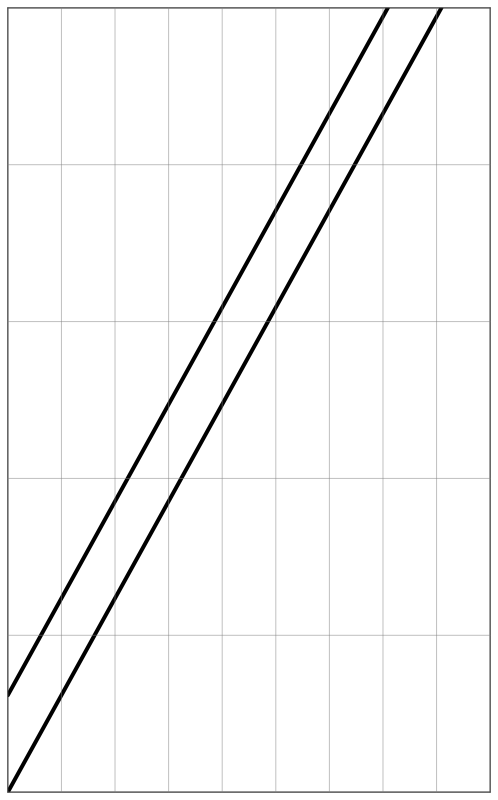

In [4]:
function plot_cut_lines(
    x::Vector{Float64},
    ys::Vector{Vector{Float64}},
    # y1::Vector{Float64},
    # y2::Vector{Float64},
    savepath::String;
    xlim::Tuple{Float64, Float64} = (minimum(x), maximum(x)),
    ylim::Tuple{Float64, Float64} = (minimum(vcat(y1, y2)) - 1, maximum(vcat(y1, y2)) + 1),
    colors::Vector{Symbol} = [:blue, :red],
    # color1::Symbol = :blue,
    # color2::Symbol = :red,
    styles::Vector{Symbol} = [:solid, :dash],
    # style1::Symbol = :solid,
    # style2::Symbol = :dash,
    transparencies::Vector{Float64} = [1.0, 0.5],
    # transparency1::Float64 = 1.0,
    # transparency2::Float64 = 0.5,
    labels::Vector{LaTeXString} = ["Line 1", "Line 2"],
    linewidth::Int = 2,
    tick_step_x::Int = 1,
    tick_step_y::Int = 1,
    xlabel::LaTeXString = L"x_1",
    ylabel::LaTeXString = L"x_2",
    labelfontsize::Int = 12,
    tickfontsize::Int = 10,
    margin::Measures.Length = 5mm,
    axis_linewidth::Int = 1,
    grid_linewidth::Int = 1,
    tick_linewidth::Int = 1
)   

    # Generate LaTeX tick labels
    xtick_labels = [L"$%$(Int(i))$" for i in floor(xlim[1]):tick_step_x:ceil(xlim[2])]
    ytick_labels = [L"$%$(Int(j))$" for j in floor(ylim[1]):tick_step_y:ceil(ylim[2])]
    xtick_positions = floor(xlim[1]):tick_step_x:ceil(xlim[2])
    ytick_positions = floor(ylim[1]):tick_step_y:ceil(ylim[2])

    plt = plot(
        size=(500, 800),
        # xlabel=xlabel,
        # ylabel=ylabel,
        legend=false,
        legendfontsize=tickfontsize,
        # legendfontfamily="Computer Modern",
        # legend=:topleft,
        xlim=xlim,
        ylim=ylim,
        grid=false,
        framestyle=:box,
        linewidth=axis_linewidth,
        # xticks=(xtick_positions, xtick_labels),  # Use positions and LaTeX labels
        # yticks=(ytick_positions, ytick_labels),
        xticks=false,
        yticks=false,
        labelfontsize=labelfontsize,
        tickfontsize=tickfontsize,
        margin=margin
    )

    for i in 1:length(ys)
        y = ys[i]
        color = colors[i]
        style = styles[i]
        transparency = transparencies[i]
        label = labels[i]
        plot!(plt, x, y, color=color, linestyle=style, alpha=transparency, linewidth=linewidth, label=label)
    end

    # plot!(plt, x, y1, color=color1, linestyle=style1, alpha=transparency1, linewidth=linewidth)
    # plot!(plt, x, y2, color=color2, linestyle=style2, alpha=transparency2, linewidth=linewidth)

    # Add custom grid lines at integer positions
    for i in floor(xlim[1]):1:ceil(xlim[2])
        vline!([i], color=:gray, alpha=0.5, linestyle=:solid, linewidth=grid_linewidth, label="")
    end
    for j in floor(ylim[1]):1:ceil(ylim[2])
        hline!([j], color=:gray, alpha=0.5, linestyle=:solid, linewidth=grid_linewidth, label="")
    end

    savefig(plt, savepath)
    return plt
end

savepath = joinpath(figure_path, "panel_1", "cut_and_project_lines.svg")
isdir(dirname(savepath)) || mkdir(dirname(savepath))

# font_size = 12

plt1 = plot_cut_lines(x1, ys, savepath;
    xlim=(0.0, 9.0),
    ylim=(0.0, 5.0),
    colors=colors,
    # color1=:blue,
    # color2=:red,
    styles=styles,
    # style1=:solid,
    # style2=:dash,
    transparencies=transparencies,
    # transparency1=1.0,
    # transparency2=0.5,
    linewidth=4,
    tick_step_x=10,
    tick_step_y=10,
    xlabel=L"X_1",
    ylabel=L"X_2",
    labelfontsize=font_size+2,
    tickfontsize=font_size,
    margin=0mm,
    axis_linewidth=2,
    grid_linewidth=1,
    tick_linewidth=1,
    labels=labels
)

## Panel 2

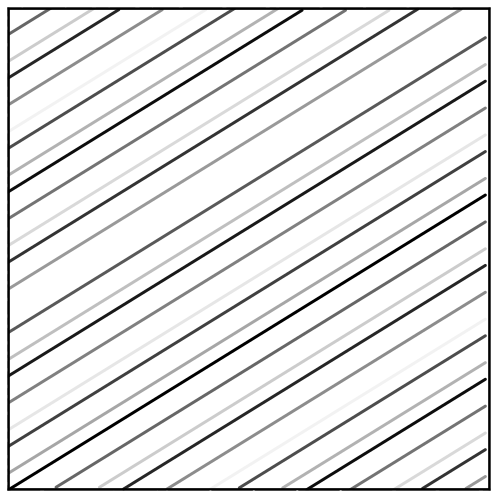

In [6]:
function plot_wrapped_cut_lines(
    x::Vector{Float64},
    ys::Vector{Vector{Float64}},
    # y1::Vector{Float64},
    # y2::Vector{Float64},
    savepath::String;
    box_size::Float64 = 1.0,
    wrap_y::Bool = true,
    xlim::Tuple{Float64, Float64} = (0.0, box_size),
    ylim::Tuple{Float64, Float64} = (0.0, box_size),
    colors::Vector{Symbol} = [:blue, :red],
    # color1::Symbol = :blue,
    # color2::Symbol = :red,
    fade_passes::Union{Int, Nothing} = nothing,
    styles::Vector{Symbol} = [:solid, :dash],
    # style1::Symbol = :solid,
    # style2::Symbol = :dash,
    transparencies::Vector{Float64} = [1.0, 1.0],
    # transparency1::Float64 = 1.0,
    # transparency2::Float64 = 1.0,
    linewidth::Int = 2,
    tick_step_x::Real = 0.5,
    tick_step_y::Real = 0.5,
    xlabel::LaTeXString = L"x_1",
    ylabel::LaTeXString = L"x_2",
    labelfontsize::Int = 12,
    tickfontsize::Int = 10,
    margin::Measures.Length = 5mm,
    axis_linewidth::Int = 1,
    grid_linewidth::Int = 1,
    tick_linewidth::Int = 1
)
    # Identify which "box" (0-1, 1-2, etc.) each point belongs to
    wrap_indices = floor.(Int, x ./ box_size)
    passes = maximum(wrap_indices, init = 0) + 1

    # Colors
    c_base = [parse(Colorant, string(c)) for c in colors]
    # c1_base = parse(Colorant, string(color1))
    # c2_base = parse(Colorant, string(color2))
    white = colorant"white"

    # Wrap coordinates
    x_mod = mod.(x, box_size)
    y_mod = [wrap_y ? mod.(y, box_size) : y for y in ys]
    # y1_mod = wrap_y ? mod.(y1, box_size) : y1
    # y2_mod = wrap_y ? mod.(y2, box_size) : y2

    # Ticks
    xtick_positions = floor(xlim[1]):tick_step_x:ceil(xlim[2])
    ytick_positions = floor(ylim[1]):tick_step_y:ceil(ylim[2])
    fmt(v) = isinteger(v) ? "$(Int(v))" : "$(round(v, digits=1))"
    xtick_labels = [L"%$s" for s in fmt.(xtick_positions)]
    ytick_labels = [L"%$s" for s in fmt.(ytick_positions)]

    plt = plot(
        size = (500, 500),
        # xlabel = xlabel,
        # ylabel = ylabel,
        legend = false,
        xlim = xlim,
        ylim = ylim,
        grid = false,
        framestyle = :box,
        linewidth = axis_linewidth,
        xticks = nothing, #(xtick_positions, xtick_labels),
        yticks = nothing, #(ytick_positions, ytick_labels),
        labelfontsize = labelfontsize,
        tickfontsize = tickfontsize,
        margin = margin
    )

    # Helper to break lines when they wrap around Y axis (vertical jump)
    function clean_jumps(xs, ys, threshold)
        nx, ny = Float64[], Float64[]
        for k in 1:length(xs)
            # If Y jumps significantly (wrapping), insert NaN to break the line
            if k > 1 && abs(ys[k] - ys[k-1]) > threshold
                push!(nx, NaN); push!(ny, NaN)
            end
            push!(nx, xs[k]); push!(ny, ys[k])
        end
        return nx, ny
    end

    for pass in 0:passes-1
        mask = wrap_indices .== pass
        if count(mask) > 1
            # Calculate fade factor: 0.0 (base color) -> approaches 1.0 (white)
            if fade_passes !== nothing
                factor = min(1.0, pass / fade_passes)
            else
                factor = passes > 1 ? pass / passes : 0.0
            end
            
            # Mix base color with white
            cols = [weighted_color_mean(1 - factor, c, white) for c in c_base]

            # Sort points within this pass by X to ensure correct line drawing
            # (Assuming x is monotonic in time, this reconstructs the segment correctly)
            current_x = x_mod[mask]
            order = sortperm(current_x)
            x_seg = current_x[order]
            
            for i in 1:length(ys)
                current_y = y_mod[i][mask]
                y_seg = current_y[order]
                
                # Clean up Y-wraps within this X-pass
                cx, cy = clean_jumps(x_seg, y_seg, box_size * 0.5)
                plot!(plt, cx, cy, c = cols[i], linewidth = linewidth, alpha = transparencies[i], linestyle = styles[i])
            end
        end
    end

    # Grid lines
    for i in floor(xlim[1]):1:ceil(xlim[2])
        vline!([i], color = :black, alpha = 1.0, linestyle = :solid, linewidth = grid_linewidth)
    end
    for j in floor(ylim[1]):1:ceil(ylim[2])
        hline!([j], color = :black, alpha = 1.0, linestyle = :solid, linewidth = grid_linewidth)
    end

    # plt = plot!(vline!([xlim[1], xlim[2]], color = :black, linewidth = tick_linewidth),
    #             hline!([ylim[1], ylim[2]], color = :black, linewidth = tick_linewidth))

    savefig(plt, savepath)
    return plt
end

ys_index = 2
ind_ys = [ys[ys_index]]
ind_colors = [colors[ys_index]]
ind_styles = [styles[ys_index]]
ind_transparencies = [transparencies[ys_index]]

savepath = joinpath(figure_path, "panel_2", "final_wrapped_cut_and_project_lines_ys$(ys_index).svg")
isdir(dirname(savepath)) || mkdir(dirname(savepath))

font_size = 20

plt1 = plot_wrapped_cut_lines(x1, ind_ys, savepath;
    box_size = 1.0,
    wrap_y = true,
    xlim = (0.0, 1.0),
    ylim = (0.0, 1.0),
    colors = ind_colors,
    fade_passes = 20,
    styles=ind_styles,
    transparencies=ind_transparencies,
    linewidth = 3,
    tick_step_x = 1,
    tick_step_y = 1,
    xlabel = L"X_1",
    ylabel = L"X_2",
    labelfontsize = font_size + 2,
    tickfontsize = font_size,
    margin = 0mm,
    axis_linewidth = 10,
    grid_linewidth = 4,
    tick_linewidth = 4
)

## Panel 3

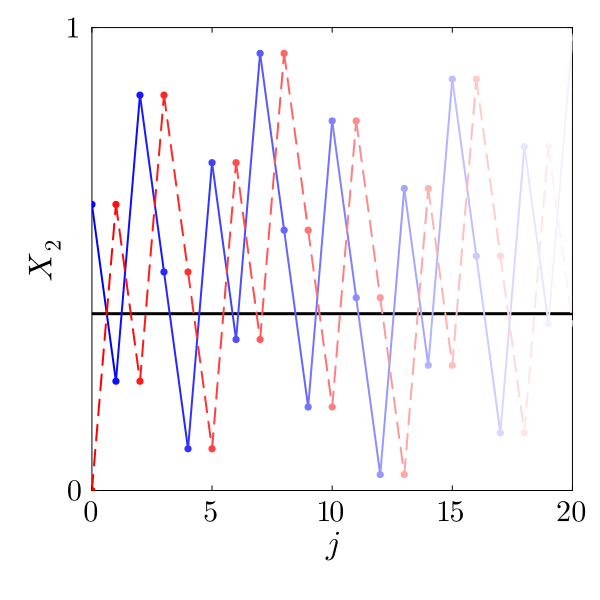

In [156]:

# Modified plot_poincare_section function with discontinuity control via fade_jump
function plot_poincare_section_disccolour(
    gamma::Float64,
    phi1::Float64,
    phi2::Float64,
    n_steps::Int,
    savepath::String;
    color1::Symbol = :blue,
    color2::Symbol = :red,
    style1::Symbol = :solid,
    style2::Symbol = :dash,
    transparency1::Float64 = 1.0,
    transparency2::Float64 = 1.0,
    linewidth::Int = 1,
    marker_size::Int = 4,
    xlabel::LaTeXString = L"n",
    ylabel::LaTeXString = L"x_2 \pmod 1",
    labelfontsize::Int = 12,
    tickfontsize::Int = 10,
    margin::Measures.Length = 5mm,
    axis_linewidth::Int = 1,
    grid_linewidth::Int = 1,
    fade_steps::Union{Int, Nothing} = nothing,
    tick_step_x::Int = 5,
    tick_step_y::Real = 1.0,
    fade_jump::Float64 = 0.1  # New parameter to control discontinuity jump size
)
    # Generate integer steps (time-like axis)
    ns = collect(0:n_steps)
    
    # Calculate intercepts at X_1 = n (which is X_1 = 0 mod 1)
    # y = gamma * x + phi
    ys1 = mod.(gamma .* ns .+ phi1, 1.0)
    ys2 = mod.(gamma .* ns .+ phi2, 1.0)

    # Generate LaTeX tick labels
    xtick_positions = 0:tick_step_x:n_steps
    ytick_positions = 0:tick_step_y:1.0
    
    xtick_labels = [L"%$i" for i in xtick_positions]
    # Format y ticks to avoid long floats, e.g., 0.2, 0.4
    fmt(v) = isinteger(v) ? "$(Int(v))" : "$(round(v, digits=1))"
    ytick_labels = [L"%$s" for s in fmt.(ytick_positions)]

    plt = plot(
        size = (600, 600),
        xlabel = xlabel,
        ylabel = ylabel,
        legend = false,
        xlim = (0, n_steps),
        ylim = (0, 1),
        grid = false,
        framestyle = :box,
        linewidth = axis_linewidth,
        labelfontsize = labelfontsize,
        tickfontsize = tickfontsize,
        xticks = (xtick_positions, xtick_labels),
        yticks = (ytick_positions, ytick_labels),
        margin = margin
    )

    # Horizontal line defining the intervals
    # A crossing occurs if y + gamma >= 1 => y >= 1 - gamma
    gamma_mod = mod(gamma, 1.0)
    threshold = 1.0 - gamma_mod
    
    hline!(plt, [threshold], color = :black, linestyle = :solid, linewidth = grid_linewidth, alpha = 1.0)

    # Colors
    c1_base = parse(Colorant, string(color1))
    c2_base = parse(Colorant, string(color2))
    white = colorant"white"

    # Plot segments with discontinuous gradient
    for i in 1:n_steps
        # Calculate fade factor with jump
        factor = min(1.0, (i-1) * fade_jump)
        
        col1 = weighted_color_mean(1 - factor, c1_base, white)
        col2 = weighted_color_mean(1 - factor, c2_base, white)

        # Line segments
        plot!(plt, ns[i:i+1], ys1[i:i+1], color = col1, linestyle = style1, linewidth = linewidth, alpha = transparency1)
        plot!(plt, ns[i:i+1], ys2[i:i+1], color = col2, linestyle = style2, linewidth = linewidth, alpha = transparency2)

        # Scatter points (start of segment)
        scatter!(plt, [ns[i]], [ys1[i]], color = col1, markersize = marker_size, markerstrokewidth = 0, alpha = transparency1)
        scatter!(plt, [ns[i]], [ys2[i]], color = col2, markersize = marker_size, markerstrokewidth = 0, alpha = transparency2)
    end
    
    # Plot the very last point with the final fade color
    last_factor = min(1.0, n_steps * fade_jump)
    col1_last = weighted_color_mean(1 - last_factor, c1_base, white)
    col2_last = weighted_color_mean(1 - last_factor, c2_base, white)
    
    scatter!(plt, [ns[end]], [ys1[end]], color = col1_last, markersize = marker_size, markerstrokewidth = 0, alpha = transparency1)
    scatter!(plt, [ns[end]], [ys2[end]], color = col2_last, markersize = marker_size, markerstrokewidth = 0, alpha = transparency2)

    savefig(plt, savepath)
    return plt
end

savepath = joinpath(figure_path, "panel_3", "poincare_section.png")
isdir(dirname(savepath)) || mkdir(dirname(savepath))

# Use same parameters as previous panels
n_steps = 20 # Corresponds to x range 0-10
fade_steps = 20

plt3 = plot_poincare_section_disccolour(
    gamma, phi1, phi2, n_steps, savepath;
    color1 = :blue,
    color2 = :red,
    style1 = :solid,
    style2 = :dash,
    transparency1 = 1.0,
    transparency2 = 1.0,
    linewidth = 2,
    marker_size = 4,
    xlabel = L"j",
    ylabel = L"X_2",
    labelfontsize = font_size + 2,
    tickfontsize = font_size,
    margin = 5mm,
    axis_linewidth = 1,
    grid_linewidth = 3,
    fade_steps = fade_steps,
    fade_jump = 0.05,
)

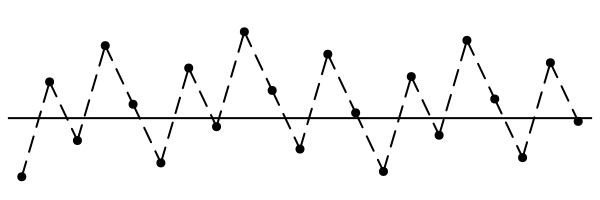

In [189]:
# ...existing code...
# New function: Clean Poincare section (scatter only, no axes/labels)
function plot_poincare_section_clean(
    gamma::Float64,
    phi::Float64,
    n_steps::Int,
    savepath::String;
    color::Symbol = :blue,
    transparency::Float64 = 1.0,
    marker_size::Int = 4,
    linewidth::Int = 2,          # New parameter
    linestyle::Symbol = :solid,  # New parameter
    margin::Measures.Length = 5mm,
    grid_linewidth::Int = 1,
    fade_jump::Float64 = 0.1,
    apply_gradient::Bool = true
)
    # Generate integer steps
    ns = collect(0:n_steps)
    
    # Calculate intercepts
    ys = mod.(gamma .* ns .+ phi, 1.0)

    # Clean plot setup with no axes
    plt = plot(
        size = (600, 200),
        legend = false,
        xlim = (-0.5, n_steps+0.5),
        ylim = (-0.1, 1.1),
        grid = false,
        axis = nothing,      # No axes
        border = :none,      # No border
        ticks = nothing,     # No ticks
        xlabel = "",
        ylabel = "",
        margin = margin
    )

    # Horizontal line defining the intervals
    # Consistent with 1-gamma logic discussed
    gamma_mod = mod(gamma, 1.0)
    threshold = 1.0 - gamma_mod
    
    # Draw threshold line for visual reference
    hline!(plt, [threshold], color = :black, linestyle = :solid, linewidth = grid_linewidth, alpha = 1.0)

    # Colors
    c_base = parse(Colorant, string(color))
    white = colorant"white"

    # Plot scatter points and lines
    for i in 1:n_steps
        if apply_gradient
            factor = min(1.0, (i-1) * fade_jump)
            col = weighted_color_mean(1 - factor, c_base, white)
        else
            col = c_base
        end

        # Draw line segment connecting i to i+1
        plot!(plt, ns[i:i+1], ys[i:i+1], color = col, linewidth = linewidth, linestyle = linestyle, alpha = transparency)
        
        # Draw point at i
        scatter!(plt, [ns[i]], [ys[i]], color = col, markersize = marker_size, markerstrokewidth = 0, alpha = transparency)
    end
    
    # Last point
    if apply_gradient
        last_factor = min(1.0, n_steps * fade_jump)
        col_last = weighted_color_mean(1 - last_factor, c_base, white)
    else
        col_last = c_base
    end

    scatter!(plt, [ns[end]], [ys[end]], color = col_last, markersize = marker_size, markerstrokewidth = 0, alpha = transparency)

    savefig(plt, savepath)
    return plt
end

ys_index = 2
phis = [phi1, phi2]
ind_ys = phis[ys_index]
ind_colors = colors[ys_index]
ind_styles = styles[ys_index]
ind_transparencies = transparencies[ys_index]

savepath = joinpath(figure_path, "panel_3", "poincare_section_clean_phi$(ys_index).svg")
# isdir(dirname(savepath)) || mkdir(dirname(savepath))

n_steps=20

# Example usage: Plotting just phi1 with gradient turned OFF
plt3_clean = plot_poincare_section_clean(
    gamma, ind_ys, n_steps, savepath;
    color = ind_colors,
    transparency = ind_transparencies,
    marker_size = 5,
    linewidth = 2,
    linestyle=ind_styles,
    margin = 0mm,
    grid_linewidth = 2,
    fade_jump = 0.05,
    apply_gradient = false
)

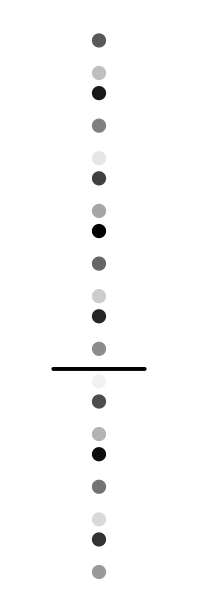

In [185]:


# New function: Vertical strip plot for a single phi (points at x=0, no axes)
function plot_poincare_vertical_strip(
    gamma::Float64,
    phi::Float64,
    n_steps::Int,
    savepath::String;
    color::Symbol = :blue,
    transparency::Float64 = 1.0,
    marker_size::Int = 6,
    margin::Measures.Length = 5mm,
    grid_linewidth::Int = 1,
    fade_jump::Float64 = 0.1
)
    # Generate integer steps
    ns = collect(0:n_steps)
    
    # Calculate intercepts y = gamma * n + phi (mod 1)
    ys = mod.(gamma .* ns .+ phi, 1.0)
    
    # All x-coordinates are 0
    xs = zeros(length(ys))

    # Setup blank plot with fixed aspect but no axes
    # Wide enough to see the dot, tall enough for 0-1 range
    plt = plot(
        size = (200, 600),
        legend = false,
        xlim = (-1, 1), # Centered around 0
        ylim = (-0.0, 1.0),
        grid = false,
        axis = nothing, # Remove axes
        border = :none, # Remove border/frame
        margin = margin
    )

    # Horizontal line defining the threshold
    gamma_mod = mod(gamma, 1.0)
    threshold = 1.0 - gamma_mod
    
    # Draw threshold line across the visible width
    plot!(plt, [-0.5, 0.5], [threshold, threshold], color = :black, linestyle = :solid, linewidth = grid_linewidth, alpha = 1.0)

    # Colors
    c_base = parse(Colorant, string(color))
    white = colorant"white"

    # Plot scatter points with discontinuous gradient
    for i in 1:n_steps
        # Calculate fade factor
        factor = min(1.0, (i-1) * fade_jump)
        col = weighted_color_mean(1 - factor, c_base, white)

        scatter!(plt, [0.0], [ys[i]], color = col, markersize = marker_size, markerstrokewidth = 0, alpha = transparency)
    end
    
    # Plot the very last point
    last_factor = min(1.0, n_steps * fade_jump)
    col_last = weighted_color_mean(1 - last_factor, c_base, white)
    scatter!(plt, [0.0], [ys[end]], color = col_last, markersize = marker_size, markerstrokewidth = 0, alpha = transparency)

    savefig(plt, savepath)
    return plt
end

ys_index = 1
phis = [phi1, phi2]
ind_ys = phis[ys_index]
ind_colors = colors[ys_index]
ind_styles = styles[ys_index]
ind_transparencies = transparencies[ys_index]

savepath_strip = joinpath(figure_path, "panel_3", "poincare_strip_phi$(ys_index).svg")
# Generate strip for phi1 (blue)
n_steps = 20

plt_strip = plot_poincare_vertical_strip(
    gamma, ind_ys, n_steps, savepath_strip;
    color = ind_colors,
    transparency = ind_transparencies,
    marker_size = 8,
    margin = 0mm,
    grid_linewidth = 4,
    fade_jump = 0.05
)

## Direct sequences

In [ ]:
function calculate_sequence(gamma::Float64, phi::Float64, n::Int)
    gamma_mod = mod(gamma, 1.0)
    threshold = 1.0 - gamma_mod
    
    # Calculate y values for steps 0 to n
    ys = mod.(gamma .* (0:n) .+ phi, 1.0)
    
    # 0 if below threshold (no crossing next step), 1 if above (crossing next step)
    # Formula: floor((j+1)g + p) - floor(jg + p)
    # This equals 1 if {jg+p} + g >= 1  =>  {jg+p} >= 1 - g
    return [y < threshold ? 0 : 1 for y in ys]
end

# Generate sequences
# We use a slightly larger N here to see the pattern better than just the 20 steps in the plot
N_print = 40 

# println("new phi: ", phi1+gamma, ", wrapped to: ", phi1+gamma - floor(phi1+gamma))

seq1 = calculate_sequence(gamma, phi1, N_print)
seq2 = calculate_sequence(gamma, 0.9, N_print)

println("Binary sequences (0: x₂ < $(round(mod(gamma,1), digits=3)), 1: x₂ > ...):")
println("-"^40)
println("Sequence 1 (Blue, ϕ = $(round(phi1, digits=3))):")
println(join(seq1))
println("-"^40)
println("Sequence 2 (Red,  ϕ = $(round(phi2, digits=3))):")
println(join(seq2))
println("-"^40)

Binary sequences (0: x₂ < 0.618, 1: x₂ > ...):
----------------------------------------
Sequence 1 (Blue, ϕ = 0.618):
10110101101101011010110110101101101011010
----------------------------------------
Sequence 2 (Red,  ϕ = 0.1):
11010110110101101101011010110110101101101
----------------------------------------


## Check sequences

In [ ]:
function cut_and_project_sequence(N::Int, gamma::Float64; phi::Float64=0.0, map_to::Tuple{Int,Int}=(1,2))
    @assert N >= 1 "N must be >= 1"
    # @assert 0.0 < gamma < 1.0 "gamma expected in (0,1) for standard Sturmian words"
    phi = phi - floor(phi) # wrap into [0,1)
    seq = Vector{Int}(undef, N)
    frac = phi
    for n in 1:N
        frac += gamma
        if frac >= 1.0
            frac -= 1.0
            # crossing an integer -> difference = 1
            seq[n] = map_to[1]   # "A"
        else
            seq[n] = map_to[2]   # "B"
        end
    end
    return seq
end

check_seq1 = cut_and_project_sequence(N_print, gamma; phi=phi1, map_to=(1,0))
check_seq2 = cut_and_project_sequence(N_print, gamma; phi=phi2, map_to=(1,0))
check_seq_high = cut_and_project_sequence(N_print, 0.99; phi=0.0, map_to=(1,0))

println("Check sequence 1 (Blue, ϕ = $(round(phi1, digits=3))): match? $(check_seq1 == seq1)")
println(join(check_seq1))
println("Check sequence 2 (Red,  ϕ = $(round(phi2, digits=3))): match? $(check_seq2 == seq2)")
println(join(check_seq2))
println("High gamma sequence (γ=0.99, ϕ=0):")
println(join(check_seq_high))



Check sequence 1 (Blue, ϕ = 0.618): match? false
1011010110110101101011011010110110101101
Check sequence 2 (Red,  ϕ = 0.1): match? false
0101101101011010110110101101101011010110
High gamma sequence (γ=0.99, ϕ=0):
0111111111111111111111111111111111111111
